In [1]:
# setting up
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

In [2]:
# settings
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
results_file = "./write/paul15.h5ad"
# low dpi (dots per inch) yields small inline figures
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

/tmp/ipykernel_16186/456379064.py:3: FutureWarning: Use `print_header` instead
  sc.logging.print_versions()
/tmp/ipykernel_16186/456379064.py:6: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")


In [3]:
adata = sc.datasets.paul15()

/workspaces/Scanpy_Trajectory_Inference_Hematopoiesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 9.82M/9.82M [00:01<00:00, 7.23MB/s]


In [4]:
# check object
adata

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [5]:
# updating precision higher than float32 (this is not required and results will be comparable without it)
adata.X = adata.X.astype("float64")

In [6]:
# preprocessing and visualization
sc.pp.recipe_zheng17(adata)

running recipe zheng17
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
    finished (0:00:00)


/workspaces/Scanpy_Trajectory_Inference_Hematopoiesis/.venv/lib/python3.12/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(


In [7]:
sc.tl.pca(adata, svd_solver="arpack")

computing PCA
    with n_comps=50
    finished (0:00:00)


In [8]:
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20)
sc.tl.draw_graph(adata)

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:17)
drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fr', graph_drawing coordinates (adata.obsm) (0:00:07)


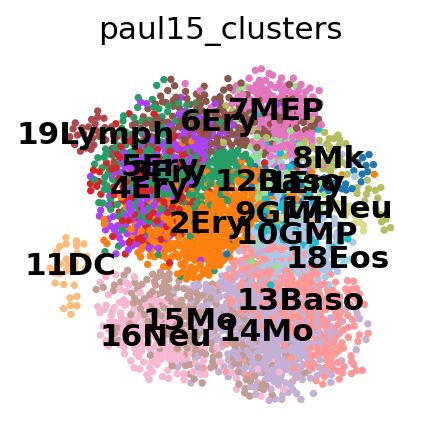

In [9]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

In [13]:
# denoising the graph (optional) by representing it in diffusion map space (and not in PCA space)
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         1.         1.         0.9997854  0.9989596  0.99872005
     0.9977957  0.9975882  0.9963799  0.99635386 0.99495196 0.9947827
     0.9938647  0.99311554 0.9920231 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [14]:
sc.tl.draw_graph(adata)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:17)


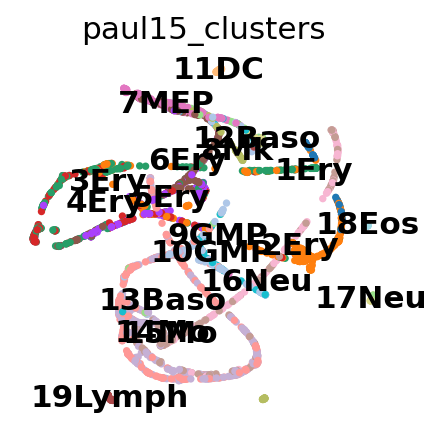

In [15]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

In [17]:
# clustering and PAGA (leiden is better, using louvain to reproduce results)
sc.tl.louvain(adata, resolution=1.0)

running Louvain clustering


ModuleNotFoundError: No module named 'louvain'